In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.random as rnd

# initial structure follows from https://github.com/stmorse/hawkes

class Hawkes:
    def __init__(self, μ = [0.1], α = [[0.5]], β=[[1.0]]):
        self.μ = np.array(μ, dtype=float)
        self.α = np.array(α, dtype=float)
        self.β = np.array(β, dtype=float)
        self.mark_dim = self.μ.shape[0]
        
        if self.α.shape != (self.mark_dim, self.mark_dim):
            raise ValueError("α must be an M x M matrix, where M is the number of mark types.")
        
        if self.β.shape != (self.mark_dim, self.mark_dim):
            raise ValueError("β must be an M x M matrix, where M is the number of mark types.")
        
        if np.any(self.μ < 0):
            raise print("All entries of μ must be nonnegative.")
        
        if np.any(self.α < 0):
            raise print("All entries of α must be nonnegative.")
        
        if np.any(self.β <= 0):
            raise print("All entries of β must be strictly positive.")
        
        abs_max_eig = np.max(np.abs(np.linalg.eigvals(self.α/self.β))) 
        print(f'Modulus of max eigenvalue: {abs_max_eig:1.5f}')
        if abs_max_eig >= 1:
            print('(WARNING) Unstable.')
        else:
            print('Appears stable')
        
        
    def check_stability(self):
        abs_max_eig = np.max(np.abs(np.linalg.eigvals(self.α/self.β))) 
        print(f'Modulus of max eigenvalue: {abs_max_eig:1.5f}')
        if abs_max_eig >= 1:
            print('(WARNING) Unstable.')
        else:
            print('Appears stable')
            
    def get_λ(self, data, t, m):
        """Compute the left-limit intensity at t"""
        if len(data) == 0:
            return self.μ[m]
        seq = np.array(data) # note that this converts the integer-valued marks in the 2nd column to floats
        seq = seq[seq[:,0] < t]
        return self.μ[m] + np.sum(np.fromiter((self.α[m,int(j)] * np.exp(-self.β[m,int(j)]*(t-t_k)) 
                                               for t_k, j in seq), dtype = float))
    
    def get_I_M(self, data, t):
        lambda_vec = np.array([self.get_λ(data, t, m) for m in range(self.mark_dim)])
        return np.cumsum(lambda_vec)
    
    def simulate(self, T, data = None):
        # data = np.empty((0, 2)) if data is None else np.array(data, dtype=float)
        data = [] if data is None else list(data)
        
        # initialization
        I_M = self.get_I_M(data, 0)
        max_intensity = I_M[-1]
        if max_intensity == 0:
            raise ValueError("Cannot generate any points if all base intensities equal 0.")
        
        # first event
        s = -1/max_intensity * np.log(rnd.uniform())
        if s > T:
            raise ValueError("T is too small for given parameters.")
        D = rnd.uniform()
        # m_i = np.argwhere(D <= I_M/max_intensity)[0][0]
        m_i = np.searchsorted(I_M/max_intensity, D)
        t_i = s
        # data = np.append(data, [[t_i, m_i]], axis = 0)
        data.append((t_i, m_i))
        
        
        # general routine
        while True:
            
            # update maximum intensity
            I_M = self.get_I_M(data, t_i) # update maximum intensity: I* <- I^M(t_{i-1}) + jump from last accepted mark
            max_intensity = I_M[-1] + np.sum(self.α[:, m_i])
            
            # this is the "current time" from which step 3.2.b proposes a new date
            s_current = t_i
            
            while True:
                # new event
                s = s_current - 1/max_intensity * np.log(rnd.uniform())
                if s > T:
                    return np.array(data)
                I_M = self.get_I_M(data, s)
                
                # Attribution-Rejection test
                D = rnd.uniform()
                if D <= I_M[-1]/max_intensity:
                    t_i = s
                    # m_i = np.argwhere(D <= I_M/max_intensity)[0][0]
                    m_i = np.searchsorted(I_M/max_intensity, D)
                    # data = np.append(data, [[t_i, m_i]], axis = 0)
                    data.append((t_i, m_i))
                    break
                else:
                    max_intensity = I_M[-1]
                    s_current = s        

In [147]:
# import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

def plot_events_and_rates(hawkes_object=None, data=None, horizon=None):

    horizon = np.amax(data[:,0]) if horizon is None else horizon
    dim = hawkes_object.mark_dim

    f, axarr = plt.subplots(
        dim*2, 1, 
        sharex='col', 
        gridspec_kw={'height_ratios':sum([[3,1] for i in range(dim)],[])}, 
        figsize=(8, dim*2)
    )

    xs = np.linspace(0, horizon, int(horizon*10))
    for i in range(dim):
        row = i * 2

        # plot rate
        r = [hawkes_object.get_λ(data, ct, i) for ct in xs]
        axarr[row].plot(xs, r)
        axarr[row].set_ylim([-0.01, np.amax(r)+(np.amax(r)/2.)])
        axarr[row].set_ylabel('$\lambda(t)_{%d}$' % i, fontsize=14)
        r = []

        # plot events
        subseq = data[data[:,1]==i][:,0]
        axarr[row+1].plot(subseq, np.zeros(len(subseq)) - 0.5, '^', alpha=0.2)
        axarr[row+1].yaxis.set_visible(False)
        axarr[row+1].set_xlim([0, horizon])

    plt.tight_layout()

Modulus of max eigenvalue: 0.37913
Appears stable


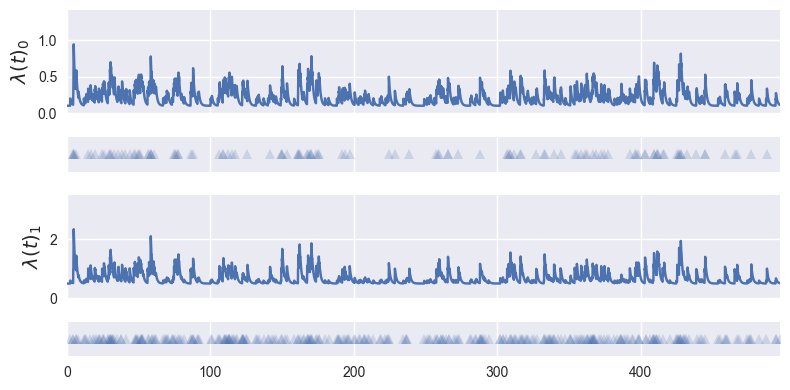

In [161]:
μ = np.array([.1, .5], dtype=float)
α = np.array([[.2, .1],
              [.5, .1]], dtype=float)
β = np.array([[1,1],
              [1,1]], dtype=float)

P2 = Hawkes(μ, α, β)
seq2 = P2.simulate(500)
plot_events_and_rates(hawkes_object=P2, data=seq2)



In [ ]:
import json
from pathlib import Path
from typing import Iterable, List, Optional, Sequence, Union

import numpy as np

try:
    from easy_tpp.utils.misc import save_json
except Exception:
    save_json = None


ArrayLike2D = Union[np.ndarray, Sequence[Sequence[float]]]


def _coerce_single_sequence(events: ArrayLike2D) -> tuple[np.ndarray, np.ndarray]:
    """
    Convert one simulated sequence of shape (n_events, 2) into:
      times: float array, sorted ascending
      types: int64 array, sorted to match times
    """
    arr = np.asarray(events)

    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError(
            f"Each sequence must have shape (n_events, 2), got {arr.shape}."
        )

    if arr.shape[0] == 0:
        raise ValueError("Empty event sequence.")

    times = np.asarray(arr[:, 0], dtype=float)
    raw_types = np.asarray(arr[:, 1], dtype=float)

    if not np.all(np.isfinite(times)):
        raise ValueError("Event times must be finite.")
    if not np.all(np.isfinite(raw_types)):
        raise ValueError("Event types must be finite.")

    rounded_types = np.rint(raw_types).astype(np.int64)
    if not np.allclose(raw_types, rounded_types):
        raise ValueError(
            "Event types must be integers (your NumPy array may be float-upcast, which is fine)."
        )

    order = np.argsort(times, kind="mergesort")
    times = times[order]
    types = rounded_types[order]

    # After sorting, times must be nondecreasing.
    if np.any(np.diff(times) < 0):
        raise ValueError("Event times must be nondecreasing.")

    return times, types


def simulate_output_to_easytpp(
    sequences: Union[ArrayLike2D, Iterable[ArrayLike2D]],
    dim_process: Optional[int] = None,
    max_seq_len: Optional[int] = None,
    type_offset: int = 0,
    start_seq_idx: int = 0,
) -> List[dict]:
    """
    Convert one simulated Hawkes sequence, or a list of simulated sequences,
    into EasyTPP / Hugging Face JSON records.

    Parameters
    ----------
    sequences
        Either:
          - a single array of shape (n_events, 2), columns = [time, type]
          - or an iterable of such arrays.
    dim_process
        Number of event types K. If None, inferred globally as max(type_event) + 1
        after subtracting `type_offset`.
    max_seq_len
        If not None, split each input sequence into chunks of at most this length.
        Each chunk becomes one EasyTPP record.
    type_offset
        Subtracted from the event-type column before saving.
        Use:
          - 0 if your types are already 0, 1, ..., K-1
          - 1 if your simulator outputs 1, 2, ..., K
    start_seq_idx
        Starting seq_idx.

    Returns
    -------
    records : list[dict]
        A list of records suitable for saving to train.json / dev.json / test.json.
    """
    # Allow either one sequence or many.
    if isinstance(sequences, np.ndarray):
        seq_list = [sequences]
    else:
        # Could still be a single nested list; detect that case.
        try:
            arr = np.asarray(sequences)
            if arr.ndim == 2 and arr.shape[1] == 2:
                seq_list = [arr]
            else:
                seq_list = list(sequences)
        except Exception:
            seq_list = list(sequences)

    coerced: list[tuple[np.ndarray, np.ndarray]] = []
    global_max_type = -1

    for seq in seq_list:
        times, types = _coerce_single_sequence(seq)

        types = types - int(type_offset)
        if np.any(types < 0):
            raise ValueError(
                "Negative event types after applying type_offset. "
                "Check whether your types are 0-based or 1-based."
            )

        if types.size > 0:
            global_max_type = max(global_max_type, int(types.max()))

        coerced.append((times, types))

    if not coerced:
        raise ValueError("No nonempty sequences provided.")

    if dim_process is None:
        dim_process = global_max_type + 1

    dim_process = int(dim_process)
    if dim_process <= 0:
        raise ValueError("dim_process must be positive.")

    records: list[dict] = []
    seq_idx = int(start_seq_idx)

    for times, types in coerced:
        if np.any(types >= dim_process):
            raise ValueError(
                f"Found event type {int(types.max())}, but dim_process={dim_process}."
            )

        chunk_len = len(times) if max_seq_len is None else int(max_seq_len)
        if chunk_len <= 0:
            raise ValueError("max_seq_len must be positive when provided.")

        for i in range(0, len(times), chunk_len):
            t_chunk = times[i : i + chunk_len]
            k_chunk = types[i : i + chunk_len]

            # Re-zero each sequence/chunk locally.
            t0 = float(t_chunk[0])
            time_since_start = t_chunk - t0

            # Recompute local interarrival times so the first entry is 0.0.
            time_since_last_event = np.empty_like(time_since_start)
            time_since_last_event[0] = 0.0
            if len(time_since_start) > 1:
                time_since_last_event[1:] = np.diff(time_since_start)

            record = {
                "dim_process": dim_process,
                "seq_idx": seq_idx,
                "seq_len": int(len(t_chunk)),
                "time_since_start": time_since_start.astype(float).tolist(),
                "time_since_last_event": time_since_last_event.astype(float).tolist(),
                "type_event": k_chunk.astype(int).tolist(),
            }
            records.append(record)
            seq_idx += 1

    return records


def save_easytpp_json(
    sequences: Union[ArrayLike2D, Iterable[ArrayLike2D]],
    out_file: Union[str, Path],
    **kwargs,
) -> List[dict]:
    """
    Convert sequence(s) and save them as EasyTPP-style JSON.
    """
    records = simulate_output_to_easytpp(sequences, **kwargs)
    out_file = str(out_file)

    if save_json is not None:
        save_json(records, out_file)
    else:
        with open(out_file, "w") as f:
            json.dump(records, f, indent=4)

    return records

[0.1 0.6]
[0.1 0.6]


In [ ]:
μ = np.array([.1, .5], dtype=float)
α = np.array([[.2, .1],
              [.5, .1]], dtype=float)
β = np.array([[1,1],
              [1,1]], dtype=float)

P2 = Hawkes(μ, α, β)
seq2 = P2.simulate(500)
plot_events_and_rates(hawkes_object=P2, data=seq2)   # shape (n_events, 2), columns = [time, type]

records = simulate_output_to_easytpp(
    seq2,
    dim_process=K,      # number of event types
    max_seq_len=None,   # or e.g. 128 if you want to chunk one long path
    type_offset=0,      # set to 1 if your types are 1..K instead of 0..K-1
)

save_easytpp_json(
    seq2,
    "train.json",
    dim_process=K,
    max_seq_len=None,
    type_offset=0,
)